In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


In [2]:
transactions = pd.read_csv("/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/transactions_2016_2017.csv")
train_target = pd.read_csv("/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/customer_clv_train.csv")
test_customers = pd.read_csv("/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/customer_clv_test.csv")

/tmp/ipykernel_2321/1995298018.py:1: DtypeWarning: Columns (0: prod_size) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv("/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/transactions_2016_2017.csv")


In [ ]:
'''
The features for each transaction are as follows:

cust_id: unique identifier of the customer placing the order
order_date: date when the order was placed
pack_date: date when the order was packed/shipped
sale_id: unique identifier of the sales transaction (multiple articles can be present in the same transaction)
sale_discount_applied: monetary value of discount applied to the sale
sale_revenue: final revenue amount received for this line item after discount
returned_to_shop_id: identifier of the shop/location where the item was returned (empty if not returned)
prod_id: unique identifier of the purchased product
prod_size: shoe size of the product
prod_web_only: binary flag (1/0) indicating whether the product is sold online only
prod_season: season or collection code (e.g., W14 = Winter 2014)
prod_brand: brand name of the product
prod_title: full commercial product name/title
prod_color: primary color of the product
prod_type_1: primary target group or category (e.g., men, women, boys)
prod_type_2: not included (= "shoes")
prod_type_3: secondary product category (e.g., sneakers, high shoes)
prod_type_4: tertiary style classification (e.g., high-top sneakers)
prod_type_5: additional style descriptor (e.g., boots with velcro, dress boots)
prod_heel: heel type or heel specification (if known)
prod_material: main outer material of the shoe (e.g., leather, suede) (if known)
prod_insole: indicator of specific insole feature (if known)
prod_print: type of print or pattern (if known)
prod_comfort_sole: indicator of special comfort sole feature (if known)
prod_comfort_wear: indicator of enhanced comfort wear feature (if known)
prod_clasp: type of closing mechanism (e.g., velcro, zipper, lace-up) (if known)
prod_outlet: indicator how often this product was sold through an outlet channel, higher values indicate that the product appeared more often

## NOTES
REAL_REVENUE = sale_revenue + sale_discount_applied
GROUPING BY CUST_ID <- MONTHS WHERE THE CUSTOMER MADE PURCHASES
GROUPING BY CUST_ID <- LENGTH OF RETURNED ITEMS (returned_to_shop_id)
PROD SIZE <- CATEGORICAL VARIABLE
PROD_TYPE_1 <- TARGET CATEGORY
PROD_TYPE_2,3,4,5 <- SPECIFIC PRODUCT CATEGORY (PREFERENCES?)
'''

In [7]:
transactions.groupby('cust_id')['sale_revenue'].sum().sort_values(ascending=False)
transactions.groupby('cust_id').size().sort_values(ascending=False)
transactions['prod_size'].unique()
transactions['prod_type_1'].unique()
#Probably exist some correlation between prod_size and prod_type_1
transactions.loc[transactions['prod_type_1'] == 'boys', 'prod_size'].value_counts()
transactions['prod_type_3'].unique() #multinomial
transactions['prod_type_4'].unique() #multi-label
transactions['prod_type_5'].unique() #Multinomial
transactions.columns
transactions['prod_material'].unique() #multi-label
transactions['prod_insole'].unique() #Binary variable, but many missing values
transactions['prod_print'].unique() #multi-label
transactions['prod_comfort_sole'].unique() #multi-label
transactions['prod_comfort_wear'].unique() #multi-label
transactions['prod_clasp'].unique() #multi-label
transactions['prod_outlet'].unique() #Binary variable
transactions['prod_heel'].unique() #ordenal categorical variable


<StringArray>
[nan, '<2.5 cm', '5-8 cm', '2.5-5 cm', '>8 cm']
Length: 5, dtype: str

In [4]:
def build_features(data, transactions):

    # -------------------------
    # COPY TRANSACTIONS
    # -------------------------
    
    trx = transactions.copy()

    trx['order_date'] = pd.to_datetime(trx['order_date'])
    trx['month_of_purchase'] = trx['order_date'].dt.month
    before = len(trx)
    trx.drop_duplicates(inplace=True)
    print(f"drop_duplicates   : {before - len(trx):,} removed ({len(trx):,} remain)")

    size_map = {'XS': 17, 'xs': 17,   # baby shoe — EU 17 (~0-6 months)
                'S':  36, 's':  36,   # adult EU small
                'M':  38, 'm':  38,   # adult EU medium
                'L':  40, 'l':  40,   # adult EU large
                'XL': 42, 'xl': 42}   # adult EU extra-large

    letter_mask = trx['prod_size'].astype(str).str.strip().isin(size_map.keys())
    if letter_mask.sum() > 0:
        cross = (trx.loc[letter_mask]
                    .assign(sz=trx.loc[letter_mask, 'prod_size'].astype(str).str.upper().str.strip())
                    .groupby(['sz', 'prod_type_1']).size().unstack(fill_value=0))
        print("encode_sizes      : letter size × product type cross-tab:")
        print(cross.to_string())

    trx['prod_size'] = trx['prod_size'].replace(size_map)
    trx['prod_size'] = pd.to_numeric(trx['prod_size'], errors='coerce')
    print(f"encode_sizes      : range {trx['prod_size'].min():.0f}–{trx['prod_size'].max():.0f}, "
          f"NaN remaining: {trx['prod_size'].isna().sum():,}")


    # -------------------------
    # CUSTOMER AGGREGATES
    # -------------------------
    
    customer_features = trx.groupby('cust_id').agg(
        customer_revenue=('sale_revenue','sum'),
        customer_purchases_number=('cust_id', lambda x: (trx.loc[x.index, 'sale_revenue'] > 0).sum()),
        avg_purchase_month=('month_of_purchase','mean')
    ).reset_index()


    # -------------------------
    # MULTI-LABEL VARIABLES
    # -------------------------
    
    multiple_labels = [
        'prod_type_3','prod_type_4','prod_type_5',
        'prod_material','prod_print',
        'prod_comfort_sole','prod_comfort_wear','prod_clasp'
    ]

    multi_features = []

    for col in multiple_labels:
        dummies = (
            trx[col]
            .fillna('unknown')
            .str.get_dummies(',')
            .add_prefix(col + '_')
        )

        dummies['cust_id'] = trx['cust_id']

        dummies = dummies.groupby('cust_id').sum().reset_index()

        multi_features.append(dummies)


    # merge all multi-label features
    for f in multi_features:
        customer_features = customer_features.merge(f, on='cust_id', how='left')


    # -------------------------
    # NORMAL CATEGORICAL
    # -------------------------
    
    multinomial_labels = ['prod_type_1','prod_insole']

    for col in multinomial_labels:

        dummies = (
            trx[col]
            .fillna('unknown')
            .str.get_dummies()
            .add_prefix(col + '_')
        )

        dummies['cust_id'] = trx['cust_id']

        dummies = dummies.groupby('cust_id').sum().reset_index()

        customer_features = customer_features.merge(dummies, on='cust_id', how='left')


    # -------------------------
    # OTHER FEATURES
    # -------------------------

    returned = trx.groupby('cust_id')['returned_to_shop_id'].apply(
        lambda x: x.notna().sum()
    ).reset_index(name='returned_items')

    customer_features = customer_features.merge(returned, on='cust_id', how='left')

    outlet = trx.groupby('cust_id')['prod_outlet'].mean().reset_index()

    customer_features = customer_features.merge(outlet, on='cust_id', how='left')


    # -------------------------
    # ORDINAL VARIABLE
    # -------------------------

    heel_map = {
        '<2.5 cm':0,
        '2.5-5 cm':1,
        '5-8 cm':2,
        '>8 cm':3
    }

    trx['prod_heel_encoded'] = trx['prod_heel'].map(heel_map).fillna(-1)

    heel = trx.groupby('cust_id')['prod_heel_encoded'].mean().reset_index()

    customer_features = customer_features.merge(heel, on='cust_id', how='left')


    # -------------------------
    # MERGE WITH INPUT DATA
    # -------------------------

    df = data[['cust_id']].merge(customer_features, on='cust_id', how='left')


    # customers without history
    df = df.fillna(0)

    return df

In [5]:
X_train = build_features(train_target, transactions)
X_test = build_features(test_customers, transactions)


drop_duplicates   : 1,063 removed (343,149 remain)
encode_sizes      : letter size × product type cross-tab:
prod_type_1  boys
sz               
XS              1
encode_sizes      : range 16–50, NaN remaining: 0
drop_duplicates   : 1,063 removed (343,149 remain)
encode_sizes      : letter size × product type cross-tab:
prod_type_1  boys
sz               
XS              1
encode_sizes      : range 16–50, NaN remaining: 0


In [6]:
y_train = (train_target['revenue_2018_2019'] > 0).astype(int)
X_train_model = X_train.drop(columns=['cust_id'])


X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_model,
    y_train,
    test_size=0.2,
    random_state=42
)

#model = DecisionTreeClassifier(
#    max_depth=6,
#    random_state=42
#)

model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=1,
    random_state=42,
)

model.fit(X_train_split, y_train_split)

X_test_model = X_test.drop(columns=['cust_id'])

predictions = model.predict(X_test_model)

0.6937359594050978


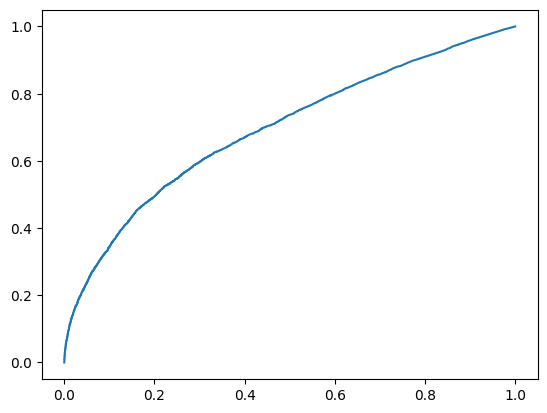

In [7]:
y_scores = model.predict_proba(X_val)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, y_scores)

roc_auc = auc(fpr, tpr)

print(roc_auc)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)

In [42]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train_model.columns
).sort_values(ascending=False)

print(importance.head(10))

customer_purchases_number    0.125737
prod_comfort_wear_unknown    0.120086
prod_comfort_sole_unknown    0.103437
customer_revenue             0.077517
prod_insole_0.0              0.070200
prod_print_unknown           0.067375
prod_type_4_unknown          0.059920
prod_material_leather        0.045081
prod_type_1_women            0.031669
prod_insole_1.0              0.029909
dtype: float64
